In [7]:
from google.colab import drive
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Drive Bağlantısı
drive.mount('/content/drive')

# 2. Yollar (Görüntüne göre güncellendi)
TRAIN_PATH = '/content/drive/MyDrive/dataset/datasets/train'
VAL_PATH = '/content/drive/MyDrive/dataset/datasets/val'

# 3. Veri Yükleyiciler (Eksik olan kısım burasıydı)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# 4. Model Kurulumu
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(5, activation='softmax') # 5 bitki türün için
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 5. Eğitim
print("Eğitim başlıyor...")
history = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen
)

# 6. Modeli Kaydet
model.save('bitirme_projesi_model.h5')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2407 images belonging to 5 classes.
Found 697 images belonging to 5 classes.
Eğitim başlıyor...
Epoch 1/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 1141s 15s/step - accuracy: 0.5409 - loss: 1.1755 - val_accuracy: 0.7044 - val_loss: 0.8286
Epoch 2/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.6710 - loss: 0.8659 - val_accuracy: 0.7504 - val_loss: 0.7424
Epoch 3/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.7204 - loss: 0.7584 - val_accuracy: 0.7834 - val_loss: 0.6437
Epoch 4/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.7403 - loss: 0.7159 - val_accuracy: 0.7877 - val_loss: 0.6448
Epoch 5/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.7557 - loss: 0.6661 - val_accuracy: 0.8178 - val_loss: 0.6007
Epoch 6/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.7586 - loss: 0.6589 - val_accuracy: 0.8077 - val_loss: 0.5799
Epoch

In [8]:
from tensorflow.keras.models import load_model

# Modeli yükle
my_model = load_model('bitirme_projesi_model.h5')

# Modelin yapısını (katmanlarını) görmek için
my_model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,391 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

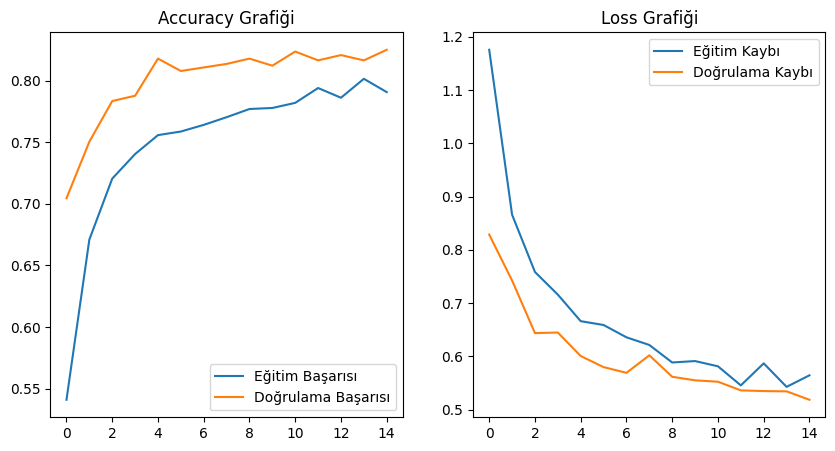

In [9]:
import matplotlib.pyplot as plt

# Başarı ve Kayıp grafiklerini çizdiriyoruz
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
plt.plot(history.history['val_accuracy'], label='Doğrulama Başarısı')
plt.title('Accuracy Grafiği')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Loss Grafiği')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
----------------------------------------
Buse, modelin tahmini: defne
Güven Oranı: %98.51
----------------------------------------


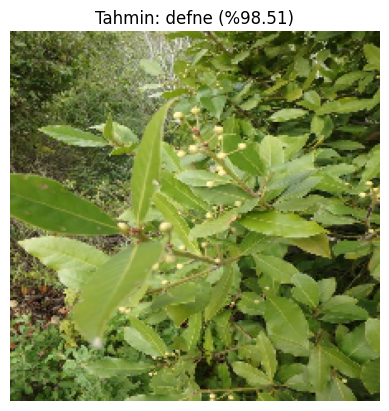

In [10]:
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# 1. Test etmek istediğin fotoğrafın Drive yolunu buraya yapıştır
# Sol taraftaki dosyalar kısmından fotoğrafa sağ tık yapıp "Yolu kopyala" diyebilirsin
test_img_path = '/content/drive/MyDrive/dataset/datasets/test/defne/fae3d01925937a7cc1b9b0dd773e314e.jpeg'

# 2. Fotoğrafı modele hazırla (224x224 boyutuna getir ve normalize et)
img = image.load_img(test_img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# 3. Tahmin yap
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions)
confidence = np.max(predictions) * 100

# 4. Sınıf isimlerini otomatik al (Klasör sırasıyla eşleşir)
class_names = sorted(os.listdir('/content/drive/MyDrive/dataset/datasets/train'))
predicted_label = class_names[predicted_class_index]

# 5. Sonucu Yazdır
print("-" * 40)
print(f"Buse, modelin tahmini: {predicted_label}")
print(f"Güven Oranı: %{confidence:.2f}")
print("-" * 40)

# Görseli ekranda göster
import matplotlib.pyplot as plt
plt.imshow(img)
plt.title(f"Tahmin: {predicted_label} (%{confidence:.2f})")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
----------------------------------------
Buse, modelin tahmini: mersin
Güven Oranı: %78.63
----------------------------------------


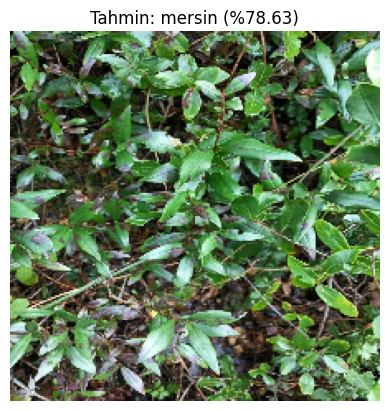

In [11]:
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# 1. Test etmek istediğin fotoğrafın Drive yolunu buraya yapıştır
# Sol taraftaki dosyalar kısmından fotoğrafa sağ tık yapıp "Yolu kopyala" diyebilirsin
test_img_path = '/content/drive/MyDrive/dataset/datasets/test/mersin/fd940e91e5926a5ead4161aa6835074f.jpeg'

# 2. Fotoğrafı modele hazırla (224x224 boyutuna getir ve normalize et)
img = image.load_img(test_img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# 3. Tahmin yap
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions)
confidence = np.max(predictions) * 100

# 4. Sınıf isimlerini otomatik al (Klasör sırasıyla eşleşir)
class_names = sorted(os.listdir('/content/drive/MyDrive/dataset/datasets/train'))
predicted_label = class_names[predicted_class_index]

# 5. Sonucu Yazdır
print("-" * 40)
print(f"Buse, modelin tahmini: {predicted_label}")
print(f"Güven Oranı: %{confidence:.2f}")
print("-" * 40)

# Görseli ekranda göster
import matplotlib.pyplot as plt
plt.imshow(img)
plt.title(f"Tahmin: {predicted_label} (%{confidence:.2f})")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
----------------------------------------
Buse, modelin tahmini: lavanta
Güven Oranı: %99.86
----------------------------------------


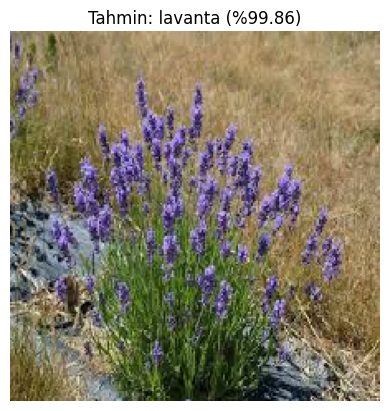

In [12]:
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# 1. Test etmek istediğin fotoğrafın Drive yolunu buraya yapıştır
# Sol taraftaki dosyalar kısmından fotoğrafa sağ tık yapıp "Yolu kopyala" diyebilirsin
test_img_path = '/content/drive/MyDrive/dataset/datasets/test/lavanta/images (16).jpeg'

# 2. Fotoğrafı modele hazırla (224x224 boyutuna getir ve normalize et)
img = image.load_img(test_img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# 3. Tahmin yap
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions)
confidence = np.max(predictions) * 100

# 4. Sınıf isimlerini otomatik al (Klasör sırasıyla eşleşir)
class_names = sorted(os.listdir('/content/drive/MyDrive/dataset/datasets/train'))
predicted_label = class_names[predicted_class_index]

# 5. Sonucu Yazdır
print("-" * 40)
print(f"Buse, modelin tahmini: {predicted_label}")
print(f"Güven Oranı: %{confidence:.2f}")
print("-" * 40)

# Görseli ekranda göster
import matplotlib.pyplot as plt
plt.imshow(img)
plt.title(f"Tahmin: {predicted_label} (%{confidence:.2f})")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
----------------------------------------
Buse, modelin tahmini: kekik
Güven Oranı: %98.17
----------------------------------------


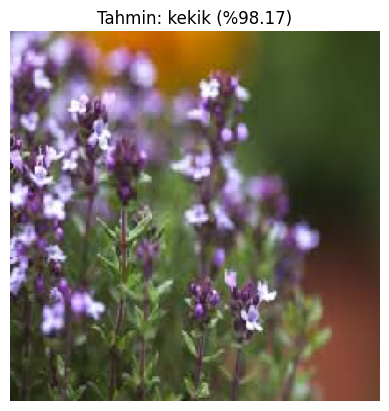

In [13]:
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# 1. Test etmek istediğin fotoğrafın Drive yolunu buraya yapıştır
# Sol taraftaki dosyalar kısmından fotoğrafa sağ tık yapıp "Yolu kopyala" diyebilirsin
test_img_path = '/content/drive/MyDrive/dataset/datasets/test/kekik/indir (1).jpg'

# 2. Fotoğrafı modele hazırla (224x224 boyutuna getir ve normalize et)
img = image.load_img(test_img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# 3. Tahmin yap
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions)
confidence = np.max(predictions) * 100

# 4. Sınıf isimlerini otomatik al (Klasör sırasıyla eşleşir)
class_names = sorted(os.listdir('/content/drive/MyDrive/dataset/datasets/train'))
predicted_label = class_names[predicted_class_index]

# 5. Sonucu Yazdır
print("-" * 40)
print(f"Buse, modelin tahmini: {predicted_label}")
print(f"Güven Oranı: %{confidence:.2f}")
print("-" * 40)

# Görseli ekranda göster
import matplotlib.pyplot as plt
plt.imshow(img)
plt.title(f"Tahmin: {predicted_label} (%{confidence:.2f})")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
----------------------------------------
Buse, modelin tahmini: ada_cayi
Güven Oranı: %90.03
----------------------------------------


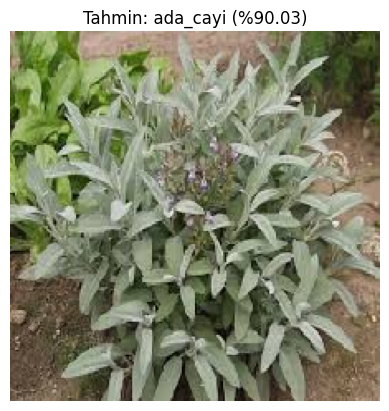

In [14]:
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# 1. Test etmek istediğin fotoğrafın Drive yolunu buraya yapıştır
# Sol taraftaki dosyalar kısmından fotoğrafa sağ tık yapıp "Yolu kopyala" diyebilirsin
test_img_path = '/content/drive/MyDrive/dataset/datasets/test/ada_cayi/images (15).jfif'

# 2. Fotoğrafı modele hazırla (224x224 boyutuna getir ve normalize et)
img = image.load_img(test_img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# 3. Tahmin yap
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions)
confidence = np.max(predictions) * 100

# 4. Sınıf isimlerini otomatik al (Klasör sırasıyla eşleşir)
class_names = sorted(os.listdir('/content/drive/MyDrive/dataset/datasets/train'))
predicted_label = class_names[predicted_class_index]

# 5. Sonucu Yazdır
print("-" * 40)
print(f"Buse, modelin tahmini: {predicted_label}")
print(f"Güven Oranı: %{confidence:.2f}")
print("-" * 40)

# Görseli ekranda göster
import matplotlib.pyplot as plt
plt.imshow(img)
plt.title(f"Tahmin: {predicted_label} (%{confidence:.2f})")
plt.axis('off')
plt.show()